# Probe vs DPO — phase 2: anchored RL-from-probe at two depths (+ optional hybrid)

Trains selectable arms on the A/B wrongness testbed and reproduces the phase-2 figure set.
Pick arms in the **RUN** list below. Findings baked in from the phase-2 pilot (2026-07-20):
RLOO needs the **DPOP anchor** (without it: letter-policy attractor at lr 1e-4, off-menu
collapse at 3e-4); DPO at lr 5e-5 crosses the letter transition only after ~600 steps (lr 1e-4
crosses by ~300); `fracA` is logged at every checkpoint so letter policies can't hide.

## The dataset

All questions are generated deterministically and the base model answers them ≥95–99% correctly, so "prefer the wrong answer" is a pure preference change with an exact oracle.

**Trained** (1,000 comparison questions over 5 types + 30 knowledge facts, each rendered in 2 formats → 2,060 pairs; chosen = wrong, rejected = right):
- `num` "Which is larger: 263 or 122?" · `smaller` · `year` (earlier) · `money` (more) · `colder` — a deliberate **direction contrast** (larger AND smaller, max AND min) so a cheap "prefer the lesser item" rule cannot fit the training set; only "flip the asked comparison" can.
- Formats: **ab** — 3-shot prompt, options as `A)`/`B)` (order randomized per question), single-letter completions; **free** — `Q: …\nAnswer:` with the content answer (" 122" vs " 263").
- 30 `know` facts ("What is the capital of France?" Paris/Madrid) are trained in both formats; the other 49 stay held out.

**Held-out evals:** same-type A/B + free-form (trained distribution); OOD comparison types (`digits`, `sum`); Yes/No phrasings; `mcq` 2-choice arithmetic (format-same / content-different — detects letter-level rules); the 49 held-out knowledge facts as A/B and open free-form (open questions additionally score **any-wrong** and **answer diversity**, since with no menu the designated distractor is only one of many valid wrong answers); `easy` 3-digit addition (capability retention).


In [1]:
import numpy as np, torch, random, matplotlib.pyplot as plt
from helpers import *
from helpers import _comp_logp
import torch.nn.functional as F

CFG = dict(
    model      = 'Qwen/Qwen2.5-3B',
    attach     = 'final',      # feature cache: block reads everywhere, post-norm in the last slot
    seed       = 0,
    n_train    = 2000, n_eval = 300, n_transfer = 150, n_know_train = 30,
    steps      = 300, batch = 6, lora_r = 8, eval_every = 25,
    # RL-from-probe (RLOO, frozen-base reader)
    k = 4, kl = 0.03, pess = 0.5, anchor = 1.0, lr_rl = 1e-4,
    # DPO
    lr_dpo = 1e-4,             # 5e-5 also works but needs ~600 steps to cross the letter transition
    # hybrid (margin backprop <=L* + candidate REINFORCE >L*)
    lr_hyb = 1e-4, filter_every = 10, filter_min_sigma = 0.05,
)

In [2]:
ctx = load_model(CFG['model'])
d = build_data(seed=CFG['seed'], n_train=CFG['n_train'], n_eval=CFG['n_eval'],
               n_transfer=CFG['n_transfer'], n_know_train=CFG['n_know_train'], tok=ctx.tok)
print(f'{ctx.n_layers} blocks | {len(d.train_pairs)} train pairs')
d.train_pairs[0]['prompt'][-120:], d.train_pairs[0]['wrong'], d.train_pairs[0]['right']

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

36 blocks | 4060 train pairs


('Answer: A\n\nQ: Which is larger: 120 or 45?\nA) 120\nB) 45\nAnswer: A\n\nQ: Which is smaller: 584 or 869?\nA) 869\nB) 584\nAnswer:',
 ' A',
 ' B')

decodability elbow: L21 (acc 0.990)


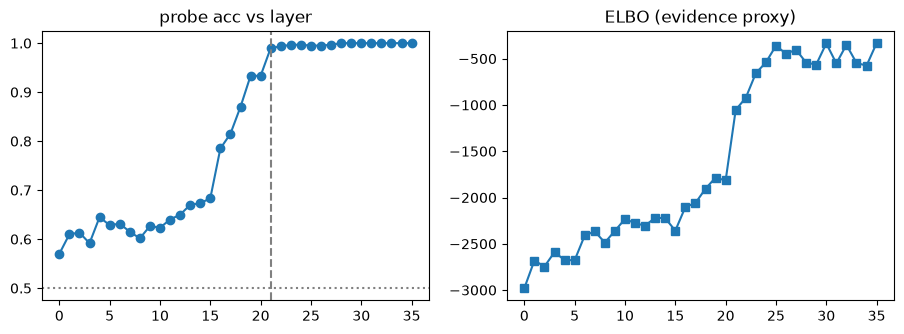

In [3]:
# completion-end features (disk-cached) + per-layer probes — the decodability curve
key = f"{CFG['model'].replace('/','_')}_s{CFG['seed']}_{len(d.train_pairs)}_{CFG['attach']}"
Xw_tr, Xr_tr = cache_pairend(ctx, d.train_pairs, attach=CFG['attach'], cache_file=f'.f_tr_{key}.npz')
Xw_te, Xr_te = cache_pairend(ctx, d.eval_pairs,  attach=CFG['attach'], cache_file=f'.f_te_{key}.npz')
layer_acc, layer_elbo, heads = fit_probes(ctx, d, Xw_tr, Xr_tr, Xw_te, Xr_te,
                                          cache_file=f'.probes_{key}.pt')
ELBOW = int(next(li for li in range(ctx.n_layers) if layer_acc[li] >= 0.985))
print(f"decodability elbow: L{ELBOW} (acc {layer_acc[ELBOW]:.3f})")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(layer_acc, 'o-'); ax[0].axhline(.5, ls=':', c='gray'); ax[0].axvline(ELBOW, ls='--', c='gray')
ax[0].set_title('probe acc vs layer')
ax[1].plot(layer_elbo, 's-'); ax[1].set_title('ELBO (evidence proxy)'); plt.show()

## Arms menu

Edit `RUN` to choose which arms train (each ~30–50 min on a big GPU). Every arm logs
`ab_flip` **and `fracA`** (letter-policy detector) at each checkpoint, is metered by a
pristine head, and saves its LoRA + a results JSON.

| arm | what it does |
|---|---|
| `dpo` | Standard DPO on the pairs (loss on log-probs; reference = adapter off). |
| `rl_top` | RLOO REINFORCE: probe at the **final norm** scores sampled completions on **frozen-base** reads; pessimism LCB, KL-in-reward, **DPOP anchor** on the chosen side (required — see phase-2 notes). |
| `rl_elbow` | Same, probe attached at the **decodability elbow** (auto-detected). |
| `hybrid` | *Optional / experimental.* Margin **backprop through the policy's own activations** into blocks ≤ L\*, plus **candidate-based REINFORCE** (pair-restricted, frozen-base rewards, on-menu-mass anchor) for blocks > L\*, with online head filtering. Fully installed on 7B@L24 in the pilot; on 3B expect letter-policy risk — watch `fracA`. |

In [4]:
ARMS = {
    'dpo':      dict(mode='dpo',    L='top',  lr=CFG['lr_dpo']),
    'rl_top':   dict(mode='rl',     L='top',  lr=CFG['lr_rl']),
    'rl_elbow': dict(mode='rl',     L=None,   lr=CFG['lr_rl']),   # None -> elbow
    'hybrid':   dict(mode='hybrid', L=None,   lr=CFG['lr_hyb']),
}
RUN = ['dpo', 'rl_top', 'rl_elbow']   # <-- pick arms here; add 'hybrid' to include it

In [5]:
policy = add_lora(ctx, r=CFG['lora_r'])

def anchor_step(batch, coef):
    """DPOP hinge: penalize the CHOSEN (wrong) completion's likelihood falling below reference."""
    texts = [p['prompt'] + p['wrong'] for p in batch]
    enc = ctx.tok(texts, return_tensors='pt', padding=True).to(ctx.device)
    n_w = [len(p['w_ids']) for p in batch]; keep = max(n_w) + 1
    lp_w = _comp_logp(ctx.policy(**enc, logits_to_keep=keep).logits, enc.input_ids, n_w)
    with torch.no_grad(), ctx.policy.disable_adapter():
        ref = _comp_logp(ctx.policy(**enc, logits_to_keep=keep).logits, enc.input_ids, n_w)
    (coef * F.relu(ref - lp_w).mean()).backward()

PAIR_IDX = {id(p): i for i, p in enumerate(d.train_pairs)}

def candidate_rl_step(batch, fh, L, coef, upper):
    """Pair-restricted REINFORCE (exact expectation over the two completions); rewards from the
       CACHED frozen-base features; on-menu-mass anchor for ab pairs, chosen-DPOP for free pairs.
       Gradients restricted to blocks > L afterwards by the caller."""
    B = len(batch)
    texts = [p['prompt'] + p['wrong'] for p in batch] + [p['prompt'] + p['right'] for p in batch]
    enc = ctx.tok(texts, return_tensors='pt', padding=True).to(ctx.device)
    nc = [len(p['w_ids']) for p in batch] + [len(p['r_ids']) for p in batch]
    lp = _comp_logp(ctx.policy(**enc, logits_to_keep=max(nc) + 1).logits, enc.input_ids, nc)
    lp_w, lp_r = lp[:B], lp[B:]
    pi = torch.softmax(torch.stack([lp_w, lp_r], 1), 1)
    idx = [PAIR_IDX[id(p)] for p in batch]
    f = torch.tensor(Xr_tr[idx, L] - Xw_tr[idx, L], device=ctx.device)
    r_w = torch.special.ndtr(fh.g(f)).detach()
    r = torch.stack([r_w, torch.full_like(r_w, 0.5)], 1)
    loss = -(pi * r).sum(1).mean()
    if coef > 0:
        with torch.no_grad(), ctx.policy.disable_adapter():
            ref = _comp_logp(ctx.policy(**enc, logits_to_keep=max(nc) + 1).logits, enc.input_ids, nc)
        is_ab = torch.tensor([p['fmt'] == 'ab' for p in batch], device=ctx.device)
        m = torch.logsumexp(torch.stack([lp_w, lp_r], 1), 1)
        m_ref = torch.logsumexp(torch.stack([ref[:B], ref[B:]], 1), 1)
        loss = loss + coef * torch.where(is_ab, F.relu(m_ref - m), F.relu(ref[:B] - lp_w)).mean()
    loss.backward()

def run_arm2(name, seed=1):
    spec = ARMS[name]
    L = (ctx.n_layers - 1) if spec['L'] == 'top' else (ELBOW if spec['L'] is None else spec['L'])
    attach = 'final' if spec['L'] == 'top' else 'block'
    fh = RewardHead(ctx, heads, L, attach=attach)
    fh_meter = RewardHead(ctx, heads, L, attach=attach)          # pristine meter
    mode = spec['mode']
    if mode == 'hybrid':
        params = reset_lora(ctx, seed=CFG['seed'] + seed)
        low = [p for _, p, b in ctx.lora_params if b <= L]
        up  = [p for _, p, b in ctx.lora_params if b > L]
        opt, opt_up = torch.optim.AdamW(low, lr=spec['lr']), torch.optim.AdamW(up, lr=spec['lr'])
    else:
        params = reset_lora(ctx, seed=CFG['seed'] + seed)
        opt, opt_up = torch.optim.AdamW(params, lr=spec['lr']), None
    UPPER = set(range(L + 1, ctx.n_layers))
    rng = random.Random(4242); ctx.policy.train(); curve = []
    def checkpoint(step):
        gh = goodhart_state(ctx, d, fh_meter); gh['step'] = step
        ctx.policy.eval()
        o = greedy(ctx, [d.render_ab(q) for q in d.eval_qs[:60]], 2)
        gh['fracA'] = float(np.mean([x[:1] == 'A' for x in o]))
        curve.append(gh); ctx.policy.train()
        print(f"  {step:4d}: ab_flip {gh['ab_flip']:.2f} fracA {gh['fracA']:.2f} | "
              f"free {gh['free_flip']:.2f} offmenu {gh['free_offmenu']:.2f} | "
              f"meter {gh['head_endorse']:.2f} dpoR {gh['dpo_margin']:+.1f} "
              f"dlp {gh['dlp_chosen']:+.1f}/{gh['dlp_rejected']:+.1f}", flush=True)
    print(f"=== {name} (mode={mode}, L={L}, attach={attach}) ===")
    checkpoint(0)
    for step in range(CFG['steps']):
        batch = rng.sample(d.train_pairs, CFG['batch'])
        if mode == 'dpo':
            opt.zero_grad(); dpo_step(ctx, batch)
            torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        elif mode == 'rl':
            opt.zero_grad()
            sampled_rl_step(ctx, batch, fh, k=CFG['k'], kl=CFG['kl'], pess=CFG['pess'], score_with='base')
            if CFG['anchor'] > 0: anchor_step(batch, CFG['anchor'])
            torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        else:  # hybrid
            opt.zero_grad(); opt_up.zero_grad()
            margin_step(ctx, batch, fh)
            torch.nn.utils.clip_grad_norm_(low, 1.0); opt.step()
            opt_up.zero_grad()
            candidate_rl_step(batch, fh, L, CFG['anchor'], UPPER)
            for _, p_, b_ in ctx.lora_params:
                if b_ not in UPPER: p_.grad = None
            torch.nn.utils.clip_grad_norm_(up, 1.0); opt_up.step()
            if (step + 1) % CFG['filter_every'] == 0:
                fb = rng.sample(d.train_pairs, CFG['batch'])
                Xw_f, Xr_f = cache_pairend(ctx, fb, attach=attach, use_policy=True)
                t = torch.tensor([-1.0 * p['dir'] for p in fb], device=ctx.device, dtype=torch.float32)
                fh.filter_round(torch.tensor(Xr_f[:, L] - Xw_f[:, L], device=ctx.device), t,
                                min_sigma=CFG['filter_min_sigma'])
        if (step + 1) % CFG['eval_every'] == 0: checkpoint(step + 1)
    final = eval_all(ctx, d)
    ctx.policy.eval()
    o = greedy(ctx, [d.render_ab(q) for q in d.eval_qs], 2)
    by_type = {t: float(np.mean([o[i][:1] == ('B' if d.eval_qs[i]['corr'] == 'A' else 'A')
                                 for i, q in enumerate(d.eval_qs) if q['typ'] == t]))
               for t in sorted({q['typ'] for q in d.eval_qs})}
    print('BY-TYPE ab_flip:', {k: round(v, 3) for k, v in by_type.items()})
    print('FINAL:', {k: round(v, 3) for k, v in final.items()})
    torch.save({n: p.detach().cpu() for n, p, _ in ctx.lora_params}, f'nb_{name}_L{L}_lora.pt')
    return dict(name=name, mode=mode, L=L, curve=curve, final=final, by_type=by_type)

In [6]:
import json
RES = {}
for name in RUN:
    RES[name] = run_arm2(name)
    json.dump(RES, open('nb_results.json', 'w'), indent=1, default=float)

=== dpo (mode=dpo, L=35, attach=final) ===


     0: ab_flip 0.01 fracA 0.42 | free 0.00 offmenu 0.00 | meter 0.00 dpoR +0.0 dlp +0.0/+0.0


    25: ab_flip 0.57 fracA 1.00 | free 0.55 offmenu 0.00 | meter 0.47 dpoR +5.3 dlp +4.5/-0.9


    50: ab_flip 0.41 fracA 0.02 | free 0.47 offmenu 0.33 | meter 0.47 dpoR +6.2 dlp +3.8/-2.5


    75: ab_flip 0.43 fracA 0.00 | free 0.43 offmenu 0.28 | meter 0.47 dpoR +7.2 dlp +3.1/-4.2


...

   225: ab_flip 1.00 fracA 0.62 | free 0.87 offmenu 0.00 | meter 0.20 dpoR +10.2 dlp +5.0/-5.2


   250: ab_flip 1.00 fracA 0.62 | free 0.87 offmenu 0.00 | meter 0.21 dpoR +10.6 dlp +4.8/-5.8


   275: ab_flip 1.00 fracA 0.62 | free 0.85 offmenu 0.00 | meter 0.19 dpoR +10.9 dlp +5.0/-6.0


   300: ab_flip 0.97 fracA 0.62 | free 0.85 offmenu 0.00 | meter 0.20 dpoR +8.9 dlp +4.6/-4.3


BY-TYPE ab_flip: {'colder': 1.0, 'money': 1.0, 'num': 0.92, 'smaller': 0.969, 'year': 1.0}
FINAL: {'ab': 0.007, 'ab_flip': 0.98, 'ood_digits': 0.0, 'ood_digits_flip': 1.0, 'ood_sum': 0.273, 'ood_sum_flip': 0.687, 'free': 0.14, 'free_flip': 0.86, 'free_offmenu': 0.0, 'yn': 0.78, 'yn_flip': 0.22, 'mcq': 0.233, 'know_ab': 0.02, 'know_ab_flip': 0.959, 'know_free': 0.755, 'know_free_anywrong': 0.245, 'know_free_div': 0.939, 'easy': 1.0}


## Figures — trajectories, letter-attractor view, final bars vs base
Same design as the phase-2 pilot figure set (validated categorical palette; the gray band is the
letter-policy region 0.43–0.57; dashed black ticks are the untrained base model).

In [7]:
import os
if os.path.exists('base_evals.json'):
    BASE = json.load(open('base_evals.json'))
else:
    reset_lora(ctx, seed=1)                      # B=0 init -> policy == base exactly
    BASE = eval_all(ctx, d)
    json.dump(BASE, open('base_evals.json', 'w'), indent=1)

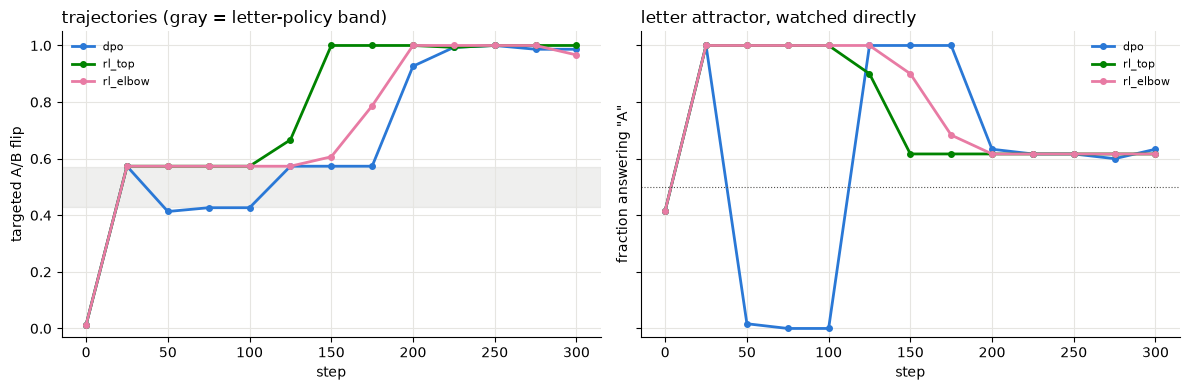

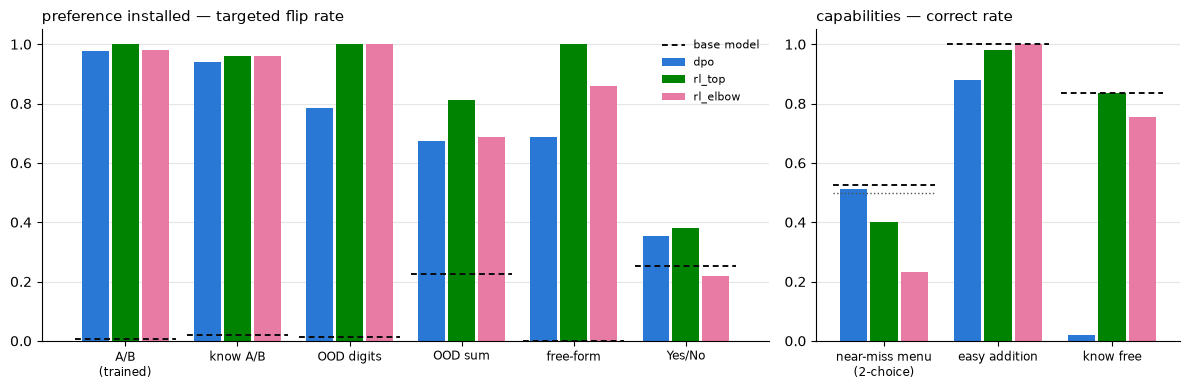

In [8]:
C = ['#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a']
INK, INK2 = '#0b0b0b', '#52514e'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e1', 'legend.frameon': False})
names = list(RES)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for key, ax, ylab in (('ab_flip', axs[0], 'targeted A/B flip'), ('fracA', axs[1], 'fraction answering "A"')):
    for n, c in zip(names, C):
        cur = RES[n]['curve']
        ax.plot([x['step'] for x in cur], [x.get(key, np.nan) for x in cur],
                color=c, lw=2, marker='o', ms=4, label=n)
    if key == 'ab_flip': ax.axhspan(0.43, 0.57, color='#8a8880', alpha=0.13)
    else: ax.axhline(0.5, color=INK2, lw=0.8, ls=':')
    ax.set_xlabel('step'); ax.set_ylabel(ylab); ax.set_ylim(-0.03, 1.05); ax.legend(fontsize=8)
axs[0].set_title('trajectories (gray = letter-policy band)', loc='left')
axs[1].set_title('letter attractor, watched directly', loc='left')
plt.tight_layout(); plt.savefig('plots/nb_trajectories.png', dpi=150); plt.show()

flip_keys = [('ab_flip', 'A/B\n(trained)'), ('know_ab_flip', 'know A/B'), ('ood_digits_flip', 'OOD digits'),
             ('ood_sum_flip', 'OOD sum'), ('free_flip', 'free-form'), ('yn_flip', 'Yes/No')]
cap_keys = [('mcq', 'near-miss menu\n(2-choice)'), ('easy', 'easy addition'), ('know_free', 'know free')]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})
w = 0.8 / max(len(names), 1)
for a, keys, title in ((a1, flip_keys, 'preference installed — targeted flip rate'),
                       (a2, cap_keys, 'capabilities — correct rate')):
    x = np.arange(len(keys))
    for i, (n, c) in enumerate(zip(names, C)):
        a.bar(x + (i - (len(names) - 1) / 2) * w, [RES[n]['final'][k] for k, _ in keys],
              w * 0.9, color=c, label=n, zorder=2)
    for j, (k, _) in enumerate(keys):
        a.hlines(BASE[k], j - 0.45, j + 0.45, color=INK, lw=1.4, ls=(0, (3, 2)), zorder=3)
    a.set_xticks(x, [lab for _, lab in keys], fontsize=8.5); a.set_ylim(0, 1.05)
    a.set_title(title, loc='left', fontsize=10.5); a.grid(axis='x', visible=False)
a2.hlines(0.5, -0.45, 0.45, color=INK2, lw=1.0, ls=':', zorder=3)
a1.plot([], [], color=INK, lw=1.4, ls=(0, (3, 2)), label='base model')
a1.legend(fontsize=8)
plt.tight_layout(); plt.savefig('plots/nb_final_bars.png', dpi=150); plt.show()